# Reto 2 – Análisis de luz

**Objetivo:** Explorar cómo la luz influye sobre la biomasa y otros parámetros.

Carga el conjunto de datos y explora las variables relevantes..

In [5]:
import pandas as pd
import matplotlib.pyplot as plt


In [6]:
datos = {
    'sitio': ['A', 'B', 'C', 'D', 'E', 'F'],
    'luz': [120, 300, 180, 450, 250, 100],
    'biomasa': [15, 35, 20, 50, 30, 10]
}

df = pd.DataFrame(datos)

df

,sitio,luz,biomasa
0,A,120,15
1,B,300,35
2,C,180,20
3,D,450,50
4,E,250,30
5,F,100,10


## Desarrollo del reto
Aplica funciones y análisis según el objetivo. Usa `def` para definir tus funciones.

In [8]:
def indice_luz(df):
    
    # Buscar la luz máxima
    luz_maxima = df['luz'].max()
    
    # Dividir cada valor entre la máxima luz
    return df['luz'] / luz_maxima

In [9]:
df['indice_luz'] = indice_luz(df)

df
indice_luz

<function __main__.indice_luz(df)>

In [10]:
p33 = df['indice_luz'].quantile(0.33)
p66 = df['indice_luz'].quantile(0.66)

print(p33)
print(p66)

0.3533333333333334
0.5888888888888889


In [11]:
def clasificar_luz(valor):
    
    if valor <= p33:
        return "baja"
    
    elif valor <= p66:
        return "media"
    
    else:
        return "alta"

In [12]:
df['categoria_luz'] = df['indice_luz'].apply(clasificar_luz)

df

,sitio,luz,biomasa,indice_luz,categoria_luz
0,A,120,15,0.266667,baja
1,B,300,35,0.666667,alta
2,C,180,20,0.400000,media
3,D,450,50,1.000000,alta
4,E,250,30,0.555556,media
5,F,100,10,0.222222,baja


In [13]:
promedio_biomasa = df.groupby('categoria_luz')['biomasa'].mean()

promedio_biomasa

categoria_luz
alta     42.5
baja     12.5
media    25.0
Name: biomasa, dtype: float64

## Interpretación de resultados
Escribe tus observaciones y conclusiones sobre los patrones encontrados.

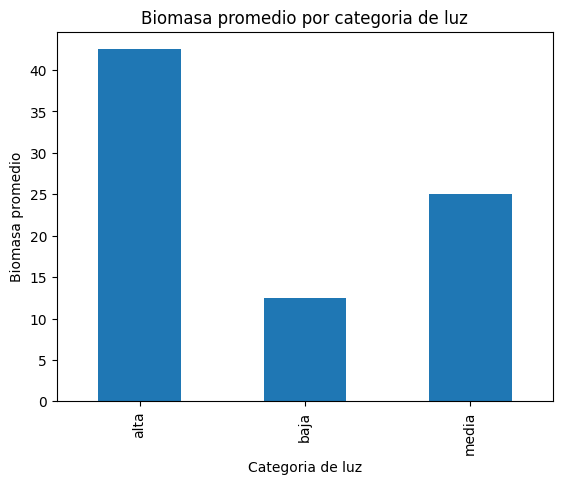

In [14]:
promedio_biomasa.plot(kind='bar')

plt.title('Biomasa promedio por categoria de luz')
plt.xlabel('Categoria de luz')
plt.ylabel('Biomasa promedio')

plt.show()